In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

In [4]:
# Reading the dataset
hmda_data = pd.read_csv("hmda_2017_ms_all-records_labels-mississipi.csv", low_memory = False)

In [5]:
# Checking dimensions of the dataset
hmda_data.shape

(101384, 78)

## Filtering the dataset

In [6]:
# filtering the dataset
hmda_data_filtered = hmda_data.loc[(hmda_data["loan_type_name"] == 'Conventional') & (hmda_data["loan_purpose_name"] == "Home purchase")]
# Taking data for loan approved / rejected
hmda_data_filtered = hmda_data_filtered.loc[hmda_data_filtered["action_taken_name"].isin(["Loan originated", "Application denied by financial institution"])]

In [7]:
# Target Distribution

hmda_data_filtered["action_taken_name"].value_counts()/hmda_data_filtered.shape[0]

action_taken_name
Loan originated                                0.674542
Application denied by financial institution    0.325458
Name: count, dtype: float64

In [303]:
# hmda_data_filtered.to_csv("hmda_data_filtered.csv", index  =False)

## Train - Validation - Test Split

In [8]:

# Step 1: First split into Train + Temp (Validation + Test)
train_df, temp_df = train_test_split(
    hmda_data_filtered,
    test_size=0.3,  # 30% = val + test
    random_state=42,
    stratify=hmda_data_filtered['action_taken_name']  # optional: stratify on target
)

# Step 2: Split temp into Validation + Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # Half of 40% = 20%
    random_state=42,
    stratify=temp_df['action_taken_name']  # optional: stratify on target
)

# Confirm sizes
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")


Train size: 16561
Validation size: 3549
Test size: 3549


## Separating Independent and Dependent Variables

In [9]:
# Define target column
target_column = 'action_taken_name'

# Split into features (X) and target (y)
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_val = val_df.drop(columns=[target_column])
y_val = val_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]



In [10]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(16561, 77) (16561,)
(3549, 77) (3549,)
(3549, 77) (3549,)


## Dropping Columns

In [11]:
# Drop unwanted columns
cols_to_drop = ["as_of_year", "respondent_id", "agency_abbr","agency_code", "loan_type_name","loan_type","property_type", "loan_purpose_name","loan_purpose",
           "owner_occupancy","preapproval","action_taken","msamd","state_name","state_abbr","state_code","county_code","applicant_ethnicity",
           "co_applicant_ethnicity","applicant_race_1","applicant_race_2","applicant_race_3","applicant_race_4","applicant_race_5","co_applicant_race_1",
           "co_applicant_race_2","co_applicant_race_3","co_applicant_race_4","co_applicant_race_5","applicant_sex","co_applicant_sex",
           "purchaser_type","denial_reason_name_1","denial_reason_1","denial_reason_name_2","denial_reason_2","denial_reason_name_3",
           "denial_reason_3","hoepa_status","lien_status","edit_status","applicant_race_name_2","applicant_race_name_3",
            "co_applicant_race_name_2","co_applicant_race_name_3","rate_spread","msamd_name"]

In [12]:
X_train_processed = X_train.drop(columns=cols_to_drop, errors='ignore')

In [13]:
X_train_processed.shape

(16561, 30)

**For Validation**

In [14]:
X_val_processed = X_val.drop(columns=cols_to_drop, errors='ignore')

In [15]:
X_val_processed.shape

(3549, 30)

**For test**

In [16]:
X_test_processed = X_test.drop(columns=cols_to_drop, errors='ignore')

In [17]:
X_test_processed.shape

(3549, 30)

**One DP**

In [18]:
one_dp_dict = X_test.iloc[0].to_dict()

In [19]:
X_one = pd.DataFrame([one_dp_dict])

In [20]:
X_one_processed = X_one.drop(columns=cols_to_drop, errors='ignore')

In [21]:
X_one_processed.shape

(1, 30)

## Drop rows that have missing values

In [22]:
# Dropping column with 100 % missing values
fully_missing_cols = X_train_processed.columns[X_train_processed.isnull().all()]
X_train_processed = X_train_processed.drop(columns=fully_missing_cols)

# Drop missing
X_train_processed = X_train_processed.dropna(subset=["county_name", "applicant_income_000s", "population"])

In [23]:
fully_missing_cols

Index(['applicant_race_name_4', 'applicant_race_name_5',
       'co_applicant_race_name_4', 'co_applicant_race_name_5',
       'edit_status_name', 'sequence_number', 'application_date_indicator'],
      dtype='object')

In [24]:
X_train_processed.shape

(14682, 23)

In [317]:
# X_train_processed.to_csv("X_train_processed.csv", index = False)

**For Validation**

In [25]:
X_val_processed = X_val_processed.drop(columns=fully_missing_cols)

# Drop missing
X_val_processed = X_val_processed.dropna(subset=["county_name", "applicant_income_000s", "population"])

In [26]:
X_val_processed.shape

(3146, 23)

**For test**

In [27]:
X_test_processed = X_test_processed.drop(columns=fully_missing_cols)

# Drop missing
X_test_processed = X_test_processed.dropna(subset=["county_name", "applicant_income_000s", "population"])

In [28]:
X_test_processed.shape

(3165, 23)

**One DP**

In [29]:
X_one_processed = X_one_processed.drop(columns=fully_missing_cols)

# Drop missing
X_one_processed = X_one_processed.dropna(subset=["county_name", "applicant_income_000s", "population"])

In [30]:
X_one_processed.shape

(1, 23)

In [31]:
X_one_processed.columns

Index(['agency_name', 'property_type_name', 'owner_occupancy_name',
       'loan_amount_000s', 'preapproval_name', 'county_name',
       'census_tract_number', 'applicant_ethnicity_name',
       'co_applicant_ethnicity_name', 'applicant_race_name_1',
       'co_applicant_race_name_1', 'applicant_sex_name',
       'co_applicant_sex_name', 'applicant_income_000s', 'purchaser_type_name',
       'hoepa_status_name', 'lien_status_name', 'population',
       'minority_population', 'hud_median_family_income',
       'tract_to_msamd_income', 'number_of_owner_occupied_units',
       'number_of_1_to_4_family_units'],
      dtype='object')

## Feature Engineering

In [32]:
X_train_processed['minority_ratio'] = X_train_processed['minority_population'] / X_train_processed['population']
X_train_processed['ownership_rate'] = X_train_processed['number_of_owner_occupied_units'] / X_train_processed['number_of_1_to_4_family_units']
X_train_processed['tract_income_deviation'] = X_train_processed['tract_to_msamd_income'] - 1
X_train_processed['wealth_density'] = X_train_processed['ownership_rate'] * X_train_processed['tract_to_msamd_income']

In [33]:
# Income binning
col = 'hud_median_family_income'
try:
    X_train_processed['income_tier'], bin_edges = pd.qcut(X_train_processed[col], q=3, retbins=True, labels=None, duplicates='drop')
    num_bins = len(bin_edges) - 1
    if num_bins < 2:
        X_train_processed['income_tier'] = 'Unknown'
    else:
        bin_labels = [f'Income_Level_{i+1}' for i in range(num_bins)]
        X_train_processed['income_tier'] = pd.cut(X_train_processed[col], bins=bin_edges, labels=bin_labels, include_lowest=True)
except Exception as e:
    X_train_processed['income_tier'] = 'Unknown'

In [34]:
bin_labels

['Income_Level_1', 'Income_Level_2']

In [35]:
bin_edges

array([45600., 53200., 61400.])

**For Validation**

In [36]:
X_val_processed['minority_ratio'] = X_val_processed['minority_population'] / X_val_processed['population']
X_val_processed['ownership_rate'] = X_val_processed['number_of_owner_occupied_units'] / X_val_processed['number_of_1_to_4_family_units']
X_val_processed['tract_income_deviation'] = X_val_processed['tract_to_msamd_income'] - 1
X_val_processed['wealth_density'] = X_val_processed['ownership_rate'] * X_val_processed['tract_to_msamd_income']

In [37]:
X_val_processed['income_tier'] = pd.cut(X_val_processed['hud_median_family_income'], bins=bin_edges, labels=bin_labels, include_lowest=True)

**For Test**

In [38]:
X_test_processed['minority_ratio'] = X_test_processed['minority_population'] / X_test_processed['population']
X_test_processed['ownership_rate'] = X_test_processed['number_of_owner_occupied_units'] / X_test_processed['number_of_1_to_4_family_units']
X_test_processed['tract_income_deviation'] = X_test_processed['tract_to_msamd_income'] - 1
X_test_processed['wealth_density'] = X_test_processed['ownership_rate'] * X_test_processed['tract_to_msamd_income']

X_test_processed['income_tier'] = pd.cut(X_test_processed['hud_median_family_income'], bins=bin_edges, labels=bin_labels, include_lowest=True)

**One DP**

In [39]:
X_one_processed['minority_ratio'] = X_one_processed['minority_population'] / X_one_processed['population']
X_one_processed['ownership_rate'] = X_one_processed['number_of_owner_occupied_units'] / X_one_processed['number_of_1_to_4_family_units']
X_one_processed['tract_income_deviation'] = X_one_processed['tract_to_msamd_income'] - 1
X_one_processed['wealth_density'] = X_one_processed['ownership_rate'] * X_one_processed['tract_to_msamd_income']

X_one_processed['income_tier'] = pd.cut(X_one_processed['hud_median_family_income'], bins=bin_edges, labels=bin_labels, include_lowest=True)

## Drop columns post feature engineering

In [40]:
# Drop post-engineering columns
cols_to_drop2 = ['census_tract_number', 'population',
                 'minority_population', 'hud_median_family_income',
                 'tract_to_msamd_income', 'number_of_owner_occupied_units',
                 'number_of_1_to_4_family_units']
X_train_processed = X_train_processed.drop(columns=cols_to_drop2, errors='ignore')

In [41]:
X_train_processed.shape

(14682, 21)

**For Validation**

In [42]:
X_val_processed = X_val_processed.drop(columns=cols_to_drop2, errors='ignore')

In [43]:
X_val_processed.shape

(3146, 21)

**For test**

In [44]:
X_test_processed = X_test_processed.drop(columns=cols_to_drop2, errors='ignore')

In [45]:
X_test_processed.shape

(3165, 21)

**One DP**

In [46]:
X_one_processed = X_one_processed.drop(columns=cols_to_drop2, errors='ignore')

In [47]:
X_one_processed.shape

(1, 21)

## Log Transformation

In [48]:
X_train_processed["applicant_income_000s"] = X_train_processed["applicant_income_000s"].apply(np.log)
X_train_processed["loan_amount_000s"] = X_train_processed["loan_amount_000s"].apply(np.log)

In [49]:
X_train_processed.shape

(14682, 21)

**For Validation**

In [50]:
X_val_processed["applicant_income_000s"] = X_val_processed["applicant_income_000s"].apply(np.log)
X_val_processed["loan_amount_000s"] = X_val_processed["loan_amount_000s"].apply(np.log)

In [51]:
X_val_processed.shape

(3146, 21)

**For test**

In [52]:
X_test_processed["applicant_income_000s"] = X_test_processed["applicant_income_000s"].apply(np.log)
X_test_processed["loan_amount_000s"] = X_test_processed["loan_amount_000s"].apply(np.log)

In [53]:
X_test_processed.shape

(3165, 21)

**One DP**

In [54]:
X_one_processed["applicant_income_000s"] = X_one_processed["applicant_income_000s"].apply(np.log)
X_one_processed["loan_amount_000s"] = X_one_processed["loan_amount_000s"].apply(np.log)

In [55]:
X_one_processed.shape

(1, 21)

## Identifying Numeric and Categorical columns

In [56]:
numerical_cols = ['loan_amount_000s', 'applicant_income_000s', 'minority_ratio',
                  'ownership_rate', 'tract_income_deviation', 'wealth_density']
categorical_cols = [
    'agency_name', 'property_type_name', 'owner_occupancy_name',
    'preapproval_name', 'county_name',
    'applicant_ethnicity_name', 'co_applicant_ethnicity_name',
    'applicant_race_name_1', 'co_applicant_race_name_1',
    'applicant_sex_name', 'co_applicant_sex_name',
    'purchaser_type_name', 'hoepa_status_name', 'lien_status_name',
    'income_tier'
]

## One-hot Encoding

In [57]:
# Gettting complete list of categorical values for each categorical column
full_categories = {}
for col in categorical_cols:
    if col != "income_tier":
        full_categories[col] = sorted(hmda_data_filtered[col].dropna().unique().tolist())
    else:
        full_categories["income_tier"]  = ['Income_Level_1', 'Income_Level_2']

In [58]:
categories_order = [full_categories[col] for col in categorical_cols]

In [59]:
ohe = OneHotEncoder(categories=categories_order,handle_unknown='ignore', sparse_output=False)

**Saving the encoder to a pickle**

In [272]:
# with open("one_hot_encoder.pkl", "wb") as f:
#     pickle.dump(ohe, f)

In [60]:
X_cat_encoded = ohe.fit_transform(X_train_processed[categorical_cols])

In [61]:
X_cat_encoded.shape

(14682, 144)

In [62]:
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=cat_feature_names, index=X_train_processed.index)

In [298]:
# with open("one_hot_encoder_cat_feature_names.pkl", "wb") as f:
#     pickle.dump(cat_feature_names, f)

In [63]:
X_cat_encoded_df.shape

(14682, 144)

**For Validation**

In [64]:
X_val_cat_encoded = ohe.transform(X_val_processed[categorical_cols])

In [65]:
X_val_cat_encoded.shape

(3146, 144)

In [66]:
X_val_cat_encoded_df = pd.DataFrame(X_val_cat_encoded, columns=cat_feature_names, index=X_val_processed.index)

In [67]:
X_val_cat_encoded_df.shape

(3146, 144)

**For test**

In [68]:
X_test_cat_encoded = ohe.transform(X_test_processed[categorical_cols])

In [69]:
X_test_cat_encoded.shape

(3165, 144)

In [70]:
X_test_cat_encoded_df = pd.DataFrame(X_test_cat_encoded, columns=cat_feature_names, index=X_test_processed.index)

In [71]:
X_test_cat_encoded_df.shape

(3165, 144)

**One DP**

In [72]:
X_one_cat_encoded = ohe.transform(X_one_processed[categorical_cols])

In [73]:
X_one_cat_encoded.shape

(1, 144)

In [74]:
X_one_cat_encoded_df = pd.DataFrame(X_one_cat_encoded, columns=cat_feature_names, index=X_one_processed.index)

In [75]:
X_one_cat_encoded_df.shape

(1, 144)

## Standardization

In [76]:
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_train_processed[numerical_cols])

In [77]:
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numerical_cols, index=X_train_processed.index)

In [78]:
X_numeric_scaled_df.shape

(14682, 6)

**For Validation**

In [79]:
X_val_numeric_scaled = scaler.transform(X_val_processed[numerical_cols])

In [80]:
X_val_numeric_scaled_df = pd.DataFrame(X_val_numeric_scaled, columns=numerical_cols, index=X_val_processed.index)

In [81]:
X_val_numeric_scaled_df.shape

(3146, 6)

**For test**

In [82]:
X_test_numeric_scaled = scaler.transform(X_test_processed[numerical_cols])
X_test_numeric_scaled_df = pd.DataFrame(X_test_numeric_scaled, columns=numerical_cols, index=X_test_processed.index)

In [83]:
X_test_numeric_scaled_df.shape

(3165, 6)

**One DP**

In [84]:
X_one_numeric_scaled = scaler.transform(X_one_processed[numerical_cols])
X_one_numeric_scaled_df = pd.DataFrame(X_one_numeric_scaled, columns=numerical_cols, index=X_one_processed.index)

In [85]:
X_one_numeric_scaled_df.shape

(1, 6)

In [299]:
# with open("standard_scalar_obj.pkl", "wb") as f:
#     pickle.dump(scaler, f)


## Combining Numeric and Categorical Features

In [86]:
X_train_final = pd.concat([X_numeric_scaled_df, X_cat_encoded_df], axis=1)

In [87]:
X_train_final.shape

(14682, 150)

**For Validation**

In [88]:
X_val_final = pd.concat([X_val_numeric_scaled_df, X_val_cat_encoded_df], axis=1)

In [89]:
X_val_final.shape

(3146, 150)

**For test**

In [90]:
X_test_final = pd.concat([X_test_numeric_scaled_df, X_test_cat_encoded_df], axis=1)

In [91]:
X_test_final.shape

(3165, 150)

**One DP**

In [92]:
X_one_final = pd.concat([X_one_numeric_scaled_df, X_one_cat_encoded_df], axis=1)

In [93]:
X_one_final.shape

(1, 150)

## Reducing Dimensions using PCA

In [94]:
pca = PCA()
X_pca = pca.fit_transform(X_train_final)

In [95]:

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

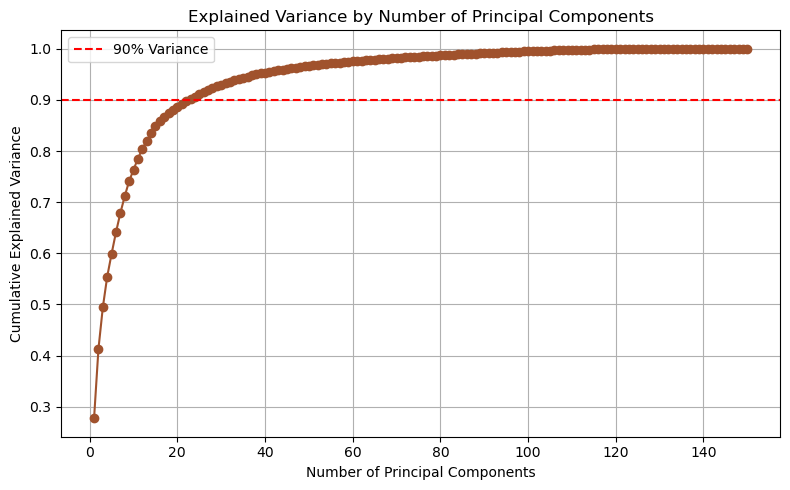

In [98]:

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color = "sienna")
plt.title('Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.legend()
plt.tight_layout()
plt.savefig("PCA_components_23.png", dpi=300, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [99]:
pca_temp = PCA().fit(X_train_final)
cumulative_variance = np.cumsum(pca_temp.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Number of components to explain 90% variance: {n_components_90}")


Number of components to explain 90% variance: 23


**Selecting 23 components**

In [100]:
# Final PCA using selected number of components
pca = PCA(n_components=23)
X_train_pca = pca.fit_transform(X_train_final)

In [101]:
X_train_pca.shape

(14682, 23)

In [102]:
X_train_processed.shape

(14682, 21)

In [103]:
y_train.shape

(16561,)

**For Validation**

In [104]:
X_val_pca = pca.transform(X_val_final)

In [105]:
X_val_pca.shape

(3146, 23)

In [106]:
X_val_processed.shape

(3146, 21)

In [107]:
y_val.shape

(3549,)

**For test**

In [108]:
X_test_pca = pca.transform(X_test_final)

In [109]:
X_test_pca.shape

(3165, 23)

**One DP**

In [110]:
X_one_pca = pca.transform(X_one_final)

In [111]:
X_one_pca.shape

(1, 23)

In [300]:
# with open("pca_obj.pkl", "wb") as f:
#     pickle.dump(pca, f)


## Indexing same rows in y_train as that of X_train_processed

This is done as after processing some rows with missing values have been dropped

In [112]:
train_indexes = list(X_train_processed.index)

In [113]:
y_train = y_train[train_indexes]

In [114]:
X_train_pca.shape, y_train.shape

((14682, 23), (14682,))

**For Validation**

In [115]:
val_indexes = list(X_val_processed.index)

In [116]:
y_val = y_val[val_indexes]

In [117]:
X_val_pca.shape, y_val.shape

((3146, 23), (3146,))

**For Test**

In [118]:
test_indexes = list(X_test_processed.index)

In [119]:
y_test = y_test[test_indexes]

In [120]:
X_test_pca.shape, y_test.shape

((3165, 23), (3165,))

## Encoding Target Variable

In [121]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


In [122]:
y_train_encoded = le.fit_transform(y_train)

**For validation**

In [123]:
y_val_encoded = le.transform(y_val)

**For test**

In [124]:
y_test_encoded = le.transform(y_test)

In [301]:
# with open("target_label_encoder.pkl", "wb") as f:
#     pickle.dump(le, f)


## Building ML Model

In [156]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [157]:

# Initialize Random Forest with class balancing
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # <- handles imbalance
)


In [158]:
# Fit the model
rf.fit(X_train_pca, y_train_encoded)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [159]:
# Predict on validation set
y_pred = rf.predict(X_val_pca)

In [160]:
# Predict on training set
y_train_pred = rf.predict(X_train_pca)

ROC-AUC Score: 0.9102


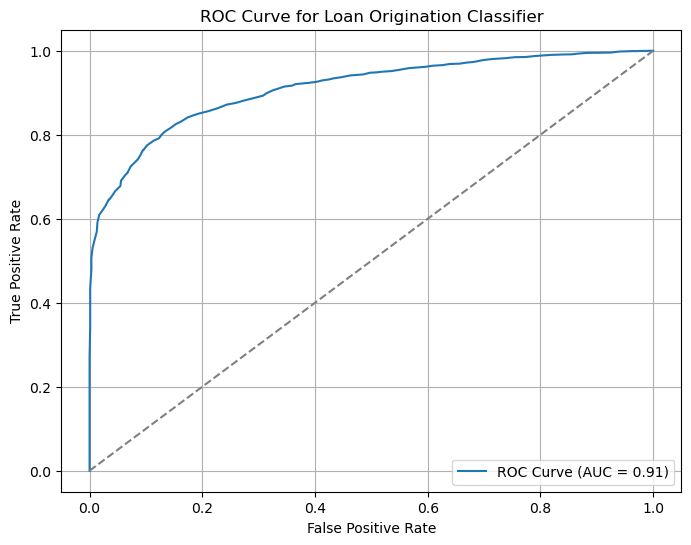

In [163]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Step 1: Get predicted probabilities (for class 1)
y_proba = rf.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [193]:
# Evaluate- Training set
print(classification_report(y_train_encoded, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, y_train_pred):.2f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4337
           1       1.00      1.00      1.00     10345

    accuracy                           1.00     14682
   macro avg       1.00      1.00      1.00     14682
weighted avg       1.00      1.00      1.00     14682

Accuracy: 1.00


In [194]:
# Evaluate- Training set
print(classification_report(y_val_encoded, y_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, y_pred):.2f}")

              precision    recall  f1-score   support

           0       0.75      0.68      0.71       933
           1       0.87      0.91      0.89      2213

    accuracy                           0.84      3146
   macro avg       0.81      0.79      0.80      3146
weighted avg       0.83      0.84      0.83      3146

Accuracy: 0.84


## Using Grid Search

In [167]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

In [168]:
from sklearn.model_selection import GridSearchCV

In [169]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_pca, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             verbose=2)

In [170]:
# Best parameters from GridSearchCV
best_params = grid_search.best_params_
print("Best parameters:", best_params)

# Best RandomForest model
best_rf = grid_search.best_estimator_

Best parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}


In [171]:
# Predict on validation set
y_pred = best_rf.predict(X_val_pca)
# Predict on training set
y_train_pred = best_rf.predict(X_train_pca)

In [172]:
# Evaluate- Training set
print(classification_report(y_train, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")

                                             precision    recall  f1-score   support

Application denied by financial institution       0.87      1.00      0.93      4337
                            Loan originated       1.00      0.94      0.97     10345

                                   accuracy                           0.95     14682
                                  macro avg       0.93      0.97      0.95     14682
                               weighted avg       0.96      0.95      0.96     14682

Accuracy: 0.95


In [173]:
# Evaluate- validation set
print(classification_report(y_val, y_pred))
print(f"Accuracy: {accuracy_score(y_val, y_pred):.2f}")

                                             precision    recall  f1-score   support

Application denied by financial institution       0.73      0.75      0.74       933
                            Loan originated       0.89      0.88      0.89      2213

                                   accuracy                           0.84      3146
                                  macro avg       0.81      0.82      0.81      3146
                               weighted avg       0.84      0.84      0.84      3146

Accuracy: 0.84


ROC-AUC Score: 0.9141


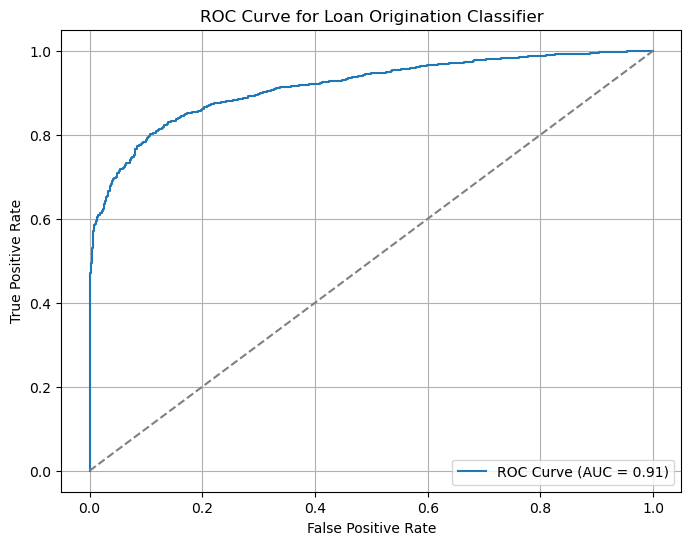

In [174]:

# Step 1: Get predicted probabilities (for class 1)
y_proba = best_rf.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# 2.

In [ ]:
{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}

In [175]:
param_grid = {
    'n_estimators': [250, 300, 350],
    'max_depth': [15, 20, 25],
    'min_samples_split': [8, 10, 12],
    'min_samples_leaf': [1, 2, 4],  # to help generalization
}


In [176]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_pca, y_train)

# Best parameters from GridSearchCV
best_params = grid_search.best_params_
print("Best parameters:", best_params)

# Best RandomForest model
best_rf = grid_search.best_estimator_

# Predict on validation set
y_pred = best_rf.predict(X_val_pca)
# Predict on training set
y_train_pred = best_rf.predict(X_train_pca)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 250}


In [177]:
# Evaluate- Training set
print(classification_report(y_train, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")

                                             precision    recall  f1-score   support

Application denied by financial institution       0.85      0.99      0.92      4337
                            Loan originated       1.00      0.93      0.96     10345

                                   accuracy                           0.95     14682
                                  macro avg       0.92      0.96      0.94     14682
                               weighted avg       0.95      0.95      0.95     14682

Accuracy: 0.95


In [178]:
# Evaluate- validation set
print(classification_report(y_val, y_pred))
print(f"Accuracy: {accuracy_score(y_val, y_pred):.2f}")

                                             precision    recall  f1-score   support

Application denied by financial institution       0.72      0.78      0.75       933
                            Loan originated       0.90      0.87      0.89      2213

                                   accuracy                           0.85      3146
                                  macro avg       0.81      0.83      0.82      3146
                               weighted avg       0.85      0.85      0.85      3146

Accuracy: 0.85


## Selected Model

ROC-AUC Score: 0.9155


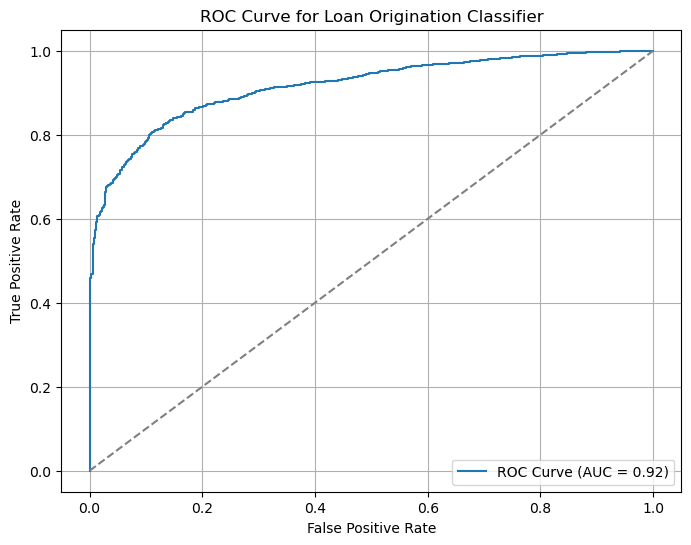

In [179]:
# Step 1: Get predicted probabilities (for class 1)
y_proba = best_rf.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# 3. 

In [ ]:
{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 250}

In [180]:
param_grid = {
    'n_estimators': [200, 250, 300],
    'max_depth': [15, 18, 20],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [2, 3, 5],# to help generalization
    'max_features': ['sqrt', 10, 15]
}


In [181]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_pca, y_train)

# Best parameters from GridSearchCV
best_params = grid_search.best_params_
print("Best parameters:", best_params)

# Best RandomForest model
best_rf = grid_search.best_estimator_

# Predict on validation set
y_pred = best_rf.predict(X_val_pca)
# Predict on training set
y_train_pred = best_rf.predict(X_train_pca)


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [182]:
# Evaluate- Training set
print(classification_report(y_train, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")

                                             precision    recall  f1-score   support

Application denied by financial institution       0.85      0.99      0.92      4337
                            Loan originated       1.00      0.93      0.96     10345

                                   accuracy                           0.95     14682
                                  macro avg       0.93      0.96      0.94     14682
                               weighted avg       0.96      0.95      0.95     14682

Accuracy: 0.95


In [183]:
# Evaluate- validation set
print(classification_report(y_val, y_pred))
print(f"Accuracy: {accuracy_score(y_val, y_pred):.2f}")

                                             precision    recall  f1-score   support

Application denied by financial institution       0.72      0.78      0.75       933
                            Loan originated       0.91      0.87      0.89      2213

                                   accuracy                           0.85      3146
                                  macro avg       0.81      0.83      0.82      3146
                               weighted avg       0.85      0.85      0.85      3146

Accuracy: 0.85


ROC-AUC Score: 0.9153


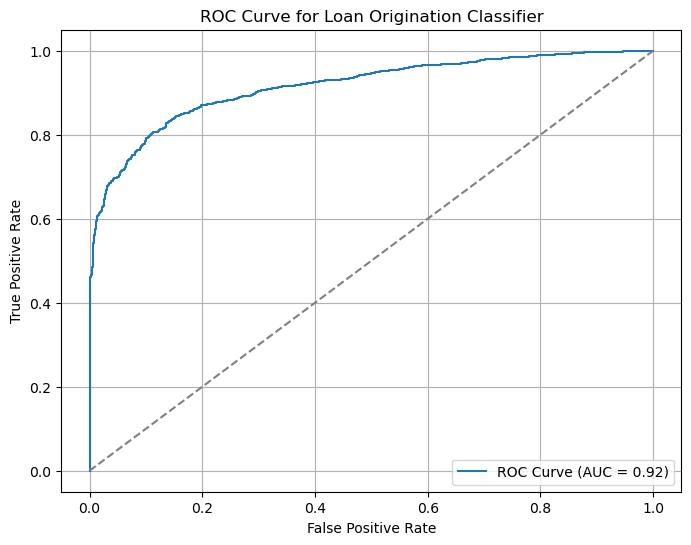

In [184]:
# Step 1: Get predicted probabilities (for class 1)
y_proba = best_rf.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [177]:
y_train

21250    Application denied by financial institution
92181                                Loan originated
51491                                Loan originated
70945    Application denied by financial institution
96026    Application denied by financial institution
                            ...                     
3078     Application denied by financial institution
86688                                Loan originated
91090    Application denied by financial institution
10988    Application denied by financial institution
43841                                Loan originated
Name: action_taken_name, Length: 14682, dtype: object

## 4

In [199]:
# param_grid = {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [185]:

# Initialize Random Forest with class balancing
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth = 20,
    max_features = "sqrt",
    min_samples_leaf = 2,
    min_samples_split = 10,
    random_state=42,
    class_weight='balanced'  # <- handles imbalance
)


In [186]:
# Fit the model
rf.fit(X_train_pca, y_train_encoded)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [187]:
# Predict on validation set
y_pred = rf.predict(X_val_pca)

# Predict on training set
y_train_pred = rf.predict(X_train_pca)


In [188]:

# Evaluate- Training set
print(classification_report(y_train_encoded, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, y_train_pred):.2f}")

# Evaluate- Training set
print(classification_report(y_val_encoded, y_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, y_pred):.2f}")


              precision    recall  f1-score   support

           0       0.85      0.99      0.92      4337
           1       1.00      0.93      0.96     10345

    accuracy                           0.95     14682
   macro avg       0.93      0.96      0.94     14682
weighted avg       0.96      0.95      0.95     14682

Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       933
           1       0.91      0.87      0.89      2213

    accuracy                           0.85      3146
   macro avg       0.81      0.83      0.82      3146
weighted avg       0.85      0.85      0.85      3146

Accuracy: 0.85


ROC-AUC Score: 0.9153


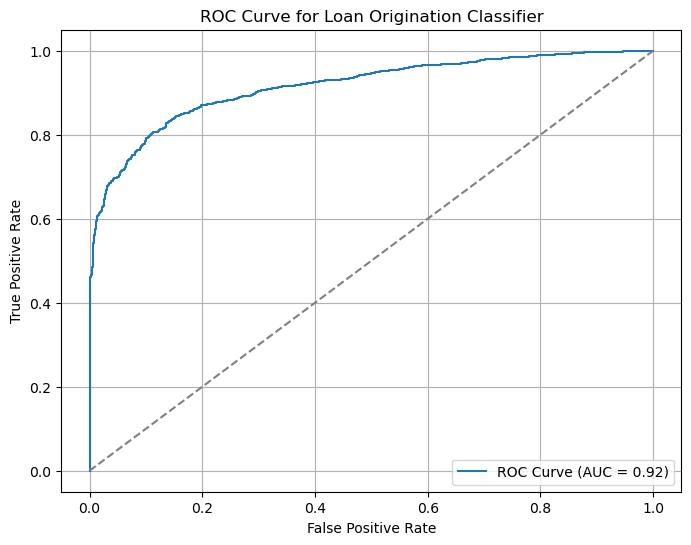

In [189]:
# Step 1: Get predicted probabilities (for class 1)
y_proba = rf.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


**Evaluation on test**

In [228]:
# Predict on test set
y_test_pred = rf.predict(X_test_pca)


In [229]:
print(classification_report(y_test_encoded, y_test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, y_test_pred):.2f}")

              precision    recall  f1-score   support

           0       0.69      0.78      0.74       948
           1       0.90      0.85      0.88      2217

    accuracy                           0.83      3165
   macro avg       0.80      0.82      0.81      3165
weighted avg       0.84      0.83      0.83      3165

Accuracy: 0.83


In [231]:
y_test_pred

array([1, 1, 1, ..., 1, 1, 0])

In [232]:
le.inverse_transform(y_test_pred)

array(['Loan originated', 'Loan originated', 'Loan originated', ...,
       'Loan originated', 'Loan originated',
       'Application denied by financial institution'], dtype=object)

**Testing on one DP**

In [268]:
rf.predict(X_one_pca)

array([1])

In [271]:
le.inverse_transform(rf.predict(X_one_pca))

array(['Loan originated'], dtype=object)

In [230]:
# import pickle

# with open("best_rf_model.pkl", "wb") as f:
#     pickle.dump(rf, f)

### XGB

In [191]:
import xgboost as xgb

In [147]:
pd.Series(y_train_encoded).value_counts()/len(y_train_encoded)

1    0.704604
0    0.295396
Name: count, dtype: float64

In [192]:
import time

In [193]:
%%time
imbalance_ratio = 70 / 30
# Define XGBClassifier model
xgb_clf = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", scale_pos_weight=imbalance_ratio)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 6, 9],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

# Grid Search with cross-validation
grid_search = GridSearchCV(xgb_clf, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=2)
grid_search.fit(X_train_pca, y_train_encoded)

# Get best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300, 'subsample': 1}
CPU times: total: 28 s
Wall time: 2min 40s


In [194]:

# Train with best parameters
best_xgb = xgb.XGBClassifier(**best_params, objective="binary:logistic", eval_metric="logloss", use_label_encoder=False)
best_xgb.fit(X_train_pca, y_train_encoded)


C:\Users\sushm\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:54:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [195]:
# Predict on validation set
y_pred = best_xgb.predict(X_val_pca)

# Predict on training set
y_train_pred = best_xgb.predict(X_train_pca)


In [196]:

# Evaluate- Training set
print(classification_report(y_train_encoded, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, y_train_pred):.2f}")

# Evaluate- Training set
print(classification_report(y_val_encoded, y_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, y_pred):.2f}")


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4337
           1       1.00      1.00      1.00     10345

    accuracy                           1.00     14682
   macro avg       1.00      1.00      1.00     14682
weighted avg       1.00      1.00      1.00     14682

Accuracy: 1.00
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       933
           1       0.88      0.89      0.89      2213

    accuracy                           0.84      3146
   macro avg       0.81      0.80      0.81      3146
weighted avg       0.84      0.84      0.84      3146

Accuracy: 0.84


ROC-AUC Score: 0.9150


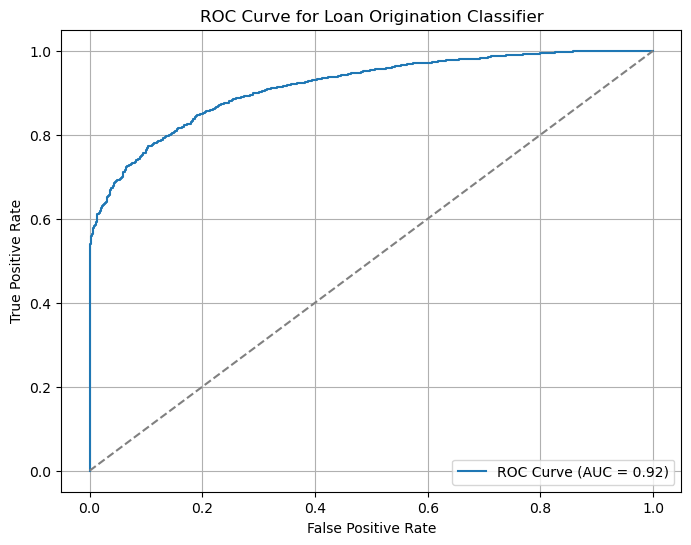

In [197]:
# Step 1: Get predicted probabilities (for class 1)
y_proba = best_xgb.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## SVM

In [125]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


In [133]:
# Initialize and train SVM
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train_encoded)

SVC(class_weight='balanced', probability=True, random_state=42)

ROC-AUC Score: 0.9121


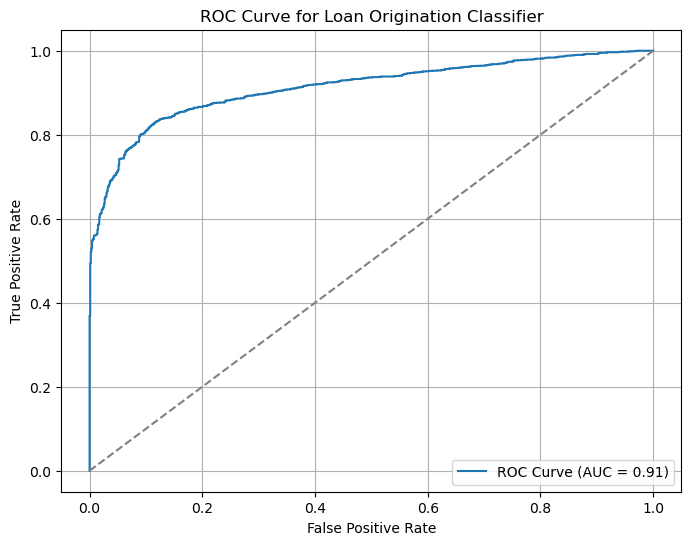

In [135]:
from sklearn.metrics import roc_auc_score, roc_curve
# Step 1: Get predicted probabilities (for class 1)
y_proba = svm_model.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [136]:
# Predict
svm_train_pred = svm_model.predict(X_train_pca)
svm_val_pred = svm_model.predict(X_val_pca)
svm_test_pred = svm_model.predict(X_test_pca)


In [137]:
# Training set
print("SVM - Training Set")
print(classification_report(y_train_encoded, svm_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, svm_train_pred):.2f}")

# Validation set
print("\n SVM - Validation Set")
print(classification_report(y_val_encoded, svm_val_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, svm_val_pred):.2f}")

# Test set
print("\n SVM - Test Set")
print(classification_report(y_test_encoded, svm_test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, svm_test_pred):.2f}")

# One data point
svm_one_pred = svm_model.predict(X_one_pca)
print("\n SVM Prediction on One DP:", le.inverse_transform(svm_one_pred)[0])

SVM - Training Set
              precision    recall  f1-score   support

           0       0.65      0.92      0.76      4337
           1       0.96      0.79      0.87     10345

    accuracy                           0.83     14682
   macro avg       0.80      0.86      0.82     14682
weighted avg       0.87      0.83      0.84     14682

Accuracy: 0.83

 SVM - Validation Set
              precision    recall  f1-score   support

           0       0.66      0.91      0.76       933
           1       0.96      0.80      0.87      2213

    accuracy                           0.83      3146
   macro avg       0.81      0.85      0.82      3146
weighted avg       0.87      0.83      0.84      3146

Accuracy: 0.83

 SVM - Test Set
              precision    recall  f1-score   support

           0       0.63      0.90      0.74       948
           1       0.95      0.77      0.85      2217

    accuracy                           0.81      3165
   macro avg       0.79      0.84      

In [126]:
from sklearn.model_selection import GridSearchCV

In [127]:
#parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1, 10],
    'kernel': ['rbf']
}


In [128]:
svm = SVC(class_weight='balanced', random_state = 12)
grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid.fit(X_train_pca, y_train_encoded)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', random_state=12),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.01, 0.1, 1, 10],
                         'kernel': ['rbf']},
             scoring='accuracy', verbose=2)

In [129]:
print("Best Parameters:", grid.best_params_)
print("Best Training Accuracy (CV mean):", grid.best_score_)

Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best Training Accuracy (CV mean): 0.821889261225054


In [130]:
# Predict
svm_train_pred = grid.predict(X_train_pca)
svm_val_pred = grid.predict(X_val_pca)
svm_test_pred = grid.predict(X_test_pca)


In [132]:
# Training set
print("SVM - Training Set")
print(classification_report(y_train_encoded, svm_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, svm_train_pred):.2f}")

# Validation set
print("\n SVM - Validation Set")
print(classification_report(y_val_encoded, svm_val_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, svm_val_pred):.2f}")

# Test set
print("\n SVM - Test Set")
print(classification_report(y_test_encoded, svm_test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, svm_test_pred):.2f}")

# # One data point
# svm_one_pred = svm_model.predict(X_one_pca)
# print("\n SVM Prediction on One DP:", le.inverse_transform(svm_one_pred)[0])

SVM - Training Set
              precision    recall  f1-score   support

           0       0.65      0.91      0.76      4337
           1       0.95      0.80      0.87     10345

    accuracy                           0.83     14682
   macro avg       0.80      0.85      0.81     14682
weighted avg       0.86      0.83      0.84     14682

Accuracy: 0.83

 SVM - Validation Set
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       933
           1       0.95      0.80      0.87      2213

    accuracy                           0.83      3146
   macro avg       0.81      0.85      0.82      3146
weighted avg       0.87      0.83      0.84      3146

Accuracy: 0.83

 SVM - Test Set
              precision    recall  f1-score   support

           0       0.63      0.89      0.74       948
           1       0.94      0.78      0.85      2217

    accuracy                           0.81      3165
   macro avg       0.79      0.83      

In [130]:
param_grid = {
    'C': [5, 7, 10, 15, 20],
    'gamma': [0.05, 0.07, 0.1, 0.2],
    'kernel': ['rbf']
}

In [131]:
svm = SVC(class_weight='balanced')
grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid.fit(X_train_pca, y_train_encoded)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=SVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [5, 7, 10, 15, 20],
                         'gamma': [0.05, 0.07, 0.1, 0.2], 'kernel': ['rbf']},
             scoring='accuracy', verbose=2)

In [132]:
print("Best Parameters:", grid.best_params_)
print("Best Training Accuracy (CV mean):", grid.best_score_)

Best Parameters: {'C': 5, 'gamma': 0.2, 'kernel': 'rbf'}
Best Training Accuracy (CV mean): 0.8210726575060837


In [134]:
# Predict
svm_train_pred = grid.predict(X_train_pca)
svm_val_pred = grid.predict(X_val_pca)
svm_test_pred = grid.predict(X_test_pca)


In [135]:
# Training set
print("SVM - Training Set")
print(classification_report(y_train_encoded, svm_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, svm_train_pred):.2f}")

# Validation set
print("\n SVM - Validation Set")
print(classification_report(y_val_encoded, svm_val_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, svm_val_pred):.2f}")

# Test set
print("\n SVM - Test Set")
print(classification_report(y_test_encoded, svm_test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, svm_test_pred):.2f}")

# One data point
svm_one_pred = svm_model.predict(X_one_pca)
print("\n SVM Prediction on One DP:", le.inverse_transform(svm_one_pred)[0])

SVM - Training Set
              precision    recall  f1-score   support

           0       0.74      0.96      0.84      4337
           1       0.98      0.86      0.92     10345

    accuracy                           0.89     14682
   macro avg       0.86      0.91      0.88     14682
weighted avg       0.91      0.89      0.89     14682

Accuracy: 0.89

 SVM - Validation Set
              precision    recall  f1-score   support

           0       0.65      0.85      0.74       933
           1       0.93      0.81      0.86      2213

    accuracy                           0.82      3146
   macro avg       0.79      0.83      0.80      3146
weighted avg       0.84      0.82      0.83      3146

Accuracy: 0.82

 SVM - Test Set
              precision    recall  f1-score   support

           0       0.63      0.85      0.73       948
           1       0.93      0.79      0.85      2217

    accuracy                           0.81      3165
   macro avg       0.78      0.82      

In [137]:
param_grid = {
    'C': [0.1, 0.5, 1, 2],
    'gamma': [0.001, 0.005, 0.01, 0.05],
    'kernel': ['rbf']
}

svm = SVC(class_weight='balanced')  # helps in class imbalance
grid = GridSearchCV(svm, param_grid, cv=10, scoring='f1', verbose=2, n_jobs=-1)
grid.fit(X_train_pca, y_train_encoded)

Fitting 10 folds for each of 16 candidates, totalling 160 fits


GridSearchCV(cv=10, estimator=SVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [0.1, 0.5, 1, 2],
                         'gamma': [0.001, 0.005, 0.01, 0.05],
                         'kernel': ['rbf']},
             scoring='f1', verbose=2)

In [138]:
print("Best Parameters:", grid.best_params_)
print("Best Training Accuracy (CV mean):", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
Best Training Accuracy (CV mean): 0.867291839578481


In [139]:
# Predict
svm_train_pred = grid.predict(X_train_pca)
svm_val_pred = grid.predict(X_val_pca)
svm_test_pred = grid.predict(X_test_pca)


In [140]:
# Training set
print("SVM - Training Set")
print(classification_report(y_train_encoded, svm_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, svm_train_pred):.2f}")

# Validation set
print("\n SVM - Validation Set")
print(classification_report(y_val_encoded, svm_val_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, svm_val_pred):.2f}")

# Test set
print("\n SVM - Test Set")
print(classification_report(y_test_encoded, svm_test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, svm_test_pred):.2f}")

# One data point
svm_one_pred = svm_model.predict(X_one_pca)
print("\n SVM Prediction on One DP:", le.inverse_transform(svm_one_pred)[0])

SVM - Training Set
              precision    recall  f1-score   support

           0       0.67      0.76      0.71      4337
           1       0.89      0.84      0.87     10345

    accuracy                           0.82     14682
   macro avg       0.78      0.80      0.79     14682
weighted avg       0.83      0.82      0.82     14682

Accuracy: 0.82

 SVM - Validation Set
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       933
           1       0.90      0.85      0.88      2213

    accuracy                           0.83      3146
   macro avg       0.80      0.82      0.81      3146
weighted avg       0.84      0.83      0.84      3146

Accuracy: 0.83

 SVM - Test Set
              precision    recall  f1-score   support

           0       0.66      0.75      0.70       948
           1       0.89      0.83      0.86      2217

    accuracy                           0.81      3165
   macro avg       0.77      0.79      

# DT

In [198]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_pca, y_train_encoded)

# Predict
dt_train_pred = dt_model.predict(X_train_pca)
dt_val_pred = dt_model.predict(X_val_pca)
dt_test_pred = dt_model.predict(X_test_pca)

# --- Evaluate Decision Tree ---

# Training set
print(" Decision Tree - Training Set")
print(classification_report(y_train_encoded, dt_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, dt_train_pred):.2f}")

# Validation set
print("\n Decision Tree - Validation Set")
print(classification_report(y_val_encoded, dt_val_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, dt_val_pred):.2f}")

# Test set
print("\n Decision Tree - Test Set")
print(classification_report(y_test_encoded, dt_test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, dt_test_pred):.2f}")

# One data point
dt_one_pred = dt_model.predict(X_one_pca)
print("\n Decision Tree Prediction on One DP:", le.inverse_transform(dt_one_pred)[0])


 Decision Tree - Training Set
              precision    recall  f1-score   support

           0       0.68      0.65      0.66      4337
           1       0.86      0.87      0.86     10345

    accuracy                           0.81     14682
   macro avg       0.77      0.76      0.76     14682
weighted avg       0.80      0.81      0.81     14682

Accuracy: 0.81

 Decision Tree - Validation Set
              precision    recall  f1-score   support

           0       0.69      0.64      0.67       933
           1       0.85      0.88      0.87      2213

    accuracy                           0.81      3146
   macro avg       0.77      0.76      0.77      3146
weighted avg       0.81      0.81      0.81      3146

Accuracy: 0.81

 Decision Tree - Test Set
              precision    recall  f1-score   support

           0       0.64      0.61      0.63       948
           1       0.84      0.85      0.84      2217

    accuracy                           0.78      3165
   macro

ROC-AUC Score: 0.8625


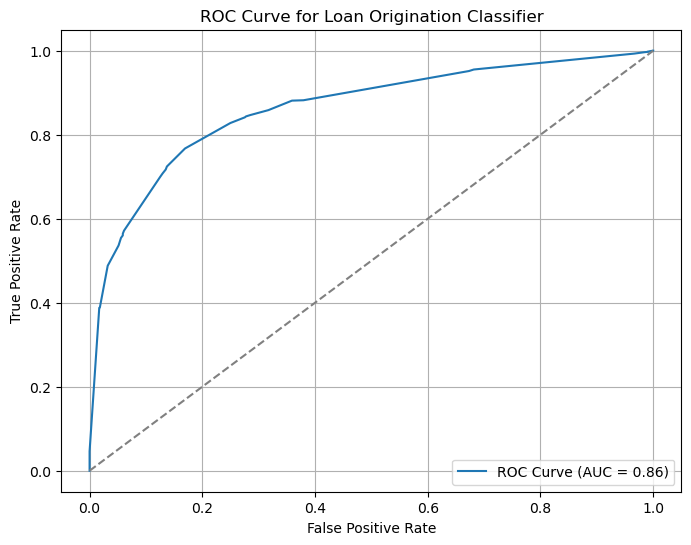

In [200]:
# Step 1: Get predicted probabilities (for class 1)
y_proba = dt_model.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## using grid search

In [201]:
# Define hyperparameters for Grid Search
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Apply GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=1)

# Fit the model using Grid Search
grid_search.fit(X_train_pca, y_train_encoded)

# Get the best model from Grid Search
best_dt_model = grid_search.best_estimator_

# Predictions using the best model
dt_train_pred = best_dt_model.predict(X_train_pca)
dt_val_pred = best_dt_model.predict(X_val_pca)
dt_test_pred = best_dt_model.predict(X_test_pca)

# --- Evaluate Decision Tree with optimized parameters ---
print(" Best Decision Tree Parameters:", grid_search.best_params_)

# Training set evaluation
print("\n Decision Tree - Training Set")
print(classification_report(y_train_encoded, dt_train_pred))
print(f"Accuracy: {accuracy_score(y_train_encoded, dt_train_pred):.2f}")

# Validation set evaluation
print("\n Decision Tree - Validation Set")
print(classification_report(y_val_encoded, dt_val_pred))
print(f"Accuracy: {accuracy_score(y_val_encoded, dt_val_pred):.2f}")

# Test set evaluation
print("\n Decision Tree - Test Set")
print(classification_report(y_test_encoded, dt_test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, dt_test_pred):.2f}")

# Predict for a single data point
dt_one_pred = best_dt_model.predict(X_one_pca)
print("\n Decision Tree Prediction on One DP:", le.inverse_transform(dt_one_pred)[0])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
 Best Decision Tree Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}

 Decision Tree - Training Set
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      4337
           1       0.92      0.91      0.91     10345

    accuracy                           0.88     14682
   macro avg       0.85      0.86      0.86     14682
weighted avg       0.88      0.88      0.88     14682

Accuracy: 0.88

 Decision Tree - Validation Set
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       933
           1       0.87      0.86      0.87      2213

    accuracy                           0.82      3146
   macro avg       0.78      0.78      0.78      3146
weighted avg       0.82      0.82      0.82      3146

Accuracy: 0.82

 Decision Tree - Test Set
              precision    recall  f1-score   support

           

ROC-AUC Score: 0.8402


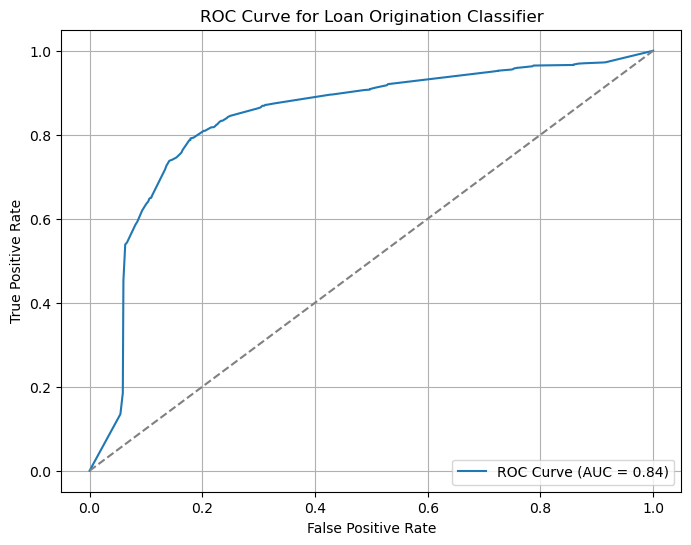

In [202]:
# Step 1: Get predicted probabilities (for class 1)
y_proba = best_dt_model.predict_proba(X_val_pca)[:, 1]  # class 1 = "loan originated"

# Step 2: Compute AUC score
roc_auc = roc_auc_score(y_val_encoded, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Step 3: Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_val_encoded, y_proba)

# Step 4: Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Origination Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [152]:
import pickle
import os
with open(os.path.join(os.getcwd(), "app", "best_rf_model.pkl"), "rb") as file:
        rf = pickle.load(file)


In [155]:
test_pred = rf.predict(X_test_pca)

In [159]:
test_pred

array([1, 1, 1, ..., 1, 1, 0])

In [156]:
y_test_encoded

array([1, 1, 1, ..., 1, 1, 0])

In [163]:

df_results = pd.DataFrame([test_pred, y_test_encoded]).T

# Add column names for clarity
df_results.columns = ['Predicted', 'Actual']


In [164]:
df_results

,Predicted,Actual
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
3160,0,0
3161,0,1
3162,1,1
3163,1,1


In [158]:
print("\n Decision Tree - Test Set")
print(classification_report(y_test_encoded, test_pred))
print(f"Accuracy: {accuracy_score(y_test_encoded, test_pred):.2f}")


 Decision Tree - Test Set
              precision    recall  f1-score   support

           0       0.69      0.78      0.74       948
           1       0.90      0.85      0.88      2217

    accuracy                           0.83      3165
   macro avg       0.80      0.82      0.81      3165
weighted avg       0.84      0.83      0.83      3165

Accuracy: 0.83
